In [1]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt

In [2]:
df=pd.read_csv("C:/Users/Dell/Downloads/data_science_job.csv")

In [8]:
df.sample(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
2788,10452,city_103,NaN,Male,No relevent experience,no_enrollment,Graduate,STEM,9.0,10000+,Pvt Ltd,308.0,0.0
7283,28159,city_61,NaN,Male,Has relevent experience,Part time course,Graduate,STEM,8.0,<10,Pvt Ltd,48.0,0.0
7722,27923,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,8.0,100-500,NaN,24.0,0.0
8751,18705,city_23,0.899,Male,Has relevent experience,no_enrollment,High School,NaN,9.0,100-500,Pvt Ltd,100.0,0.0
983,20747,city_36,0.893,Male,Has relevent experience,no_enrollment,Masters,STEM,8.0,10000+,Pvt Ltd,NaN,0.0
7100,4589,city_21,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,5.0,100-500,Pvt Ltd,30.0,1.0
16381,24819,city_14,0.698,Male,Has relevent experience,no_enrollment,Masters,STEM,9.0,5000-9999,Pvt Ltd,31.0,0.0
13991,12591,city_114,0.926,Male,No relevent experience,no_enrollment,High School,NaN,2.0,NaN,NaN,48.0,0.0
9917,15334,city_99,0.915,Male,Has relevent experience,no_enrollment,Masters,STEM,9.0,10000+,Public Sector,68.0,1.0
15347,23847,city_103,0.920,Male,No relevent experience,no_enrollment,Primary School,NaN,4.0,NaN,NaN,15.0,0.0


In [9]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'training_hours', 'target'],
      dtype='object')

In [6]:
df.shape

(19158, 13)

In [16]:
cols=[]
for var in df.columns:
    missing=df[var].isnull().mean()

    if missing > 0 and missing <0.05:
        cols.append(var)
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [17]:
df[cols].sample(10)

,city_development_index,enrolled_university,education_level,experience,training_hours
19126,0.910,no_enrollment,Graduate,6.0,150.0
2873,0.910,no_enrollment,Graduate,3.0,2.0
3582,0.920,Full time course,Graduate,13.0,256.0
15868,0.920,no_enrollment,Graduate,20.0,26.0
2025,0.926,no_enrollment,Masters,8.0,6.0
11108,0.896,no_enrollment,Graduate,5.0,50.0
16149,0.855,Full time course,Graduate,7.0,38.0
1906,0.796,Full time course,Graduate,9.0,29.0
7930,0.920,no_enrollment,Graduate,15.0,52.0
3847,0.926,Part time course,Graduate,15.0,83.0


In [19]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [20]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

In [21]:
df[cols].isnull().sum()

city_development_index    479
enrolled_university       386
education_level           460
experience                 65
training_hours            766
dtype: int64

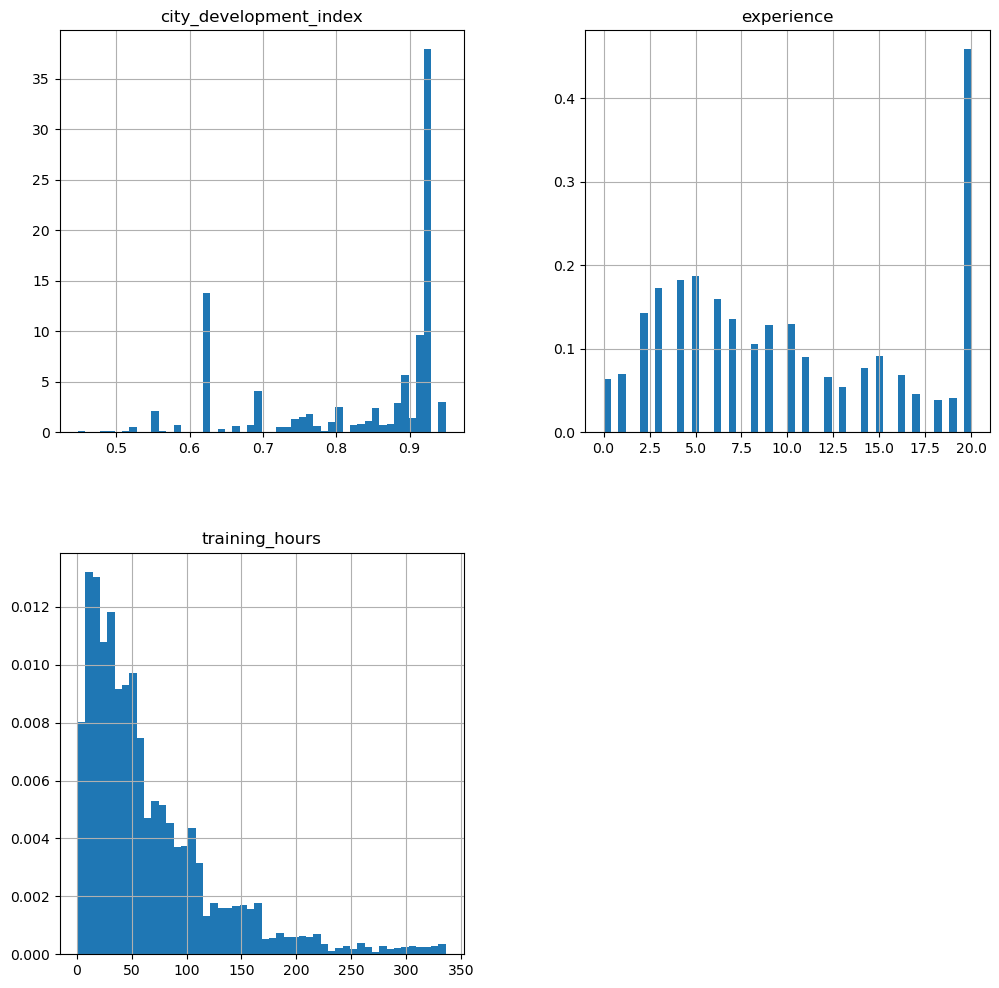

In [22]:
new_df.hist(bins=50,density=True,figsize=(12,12))
plt.show()


<Axes: >

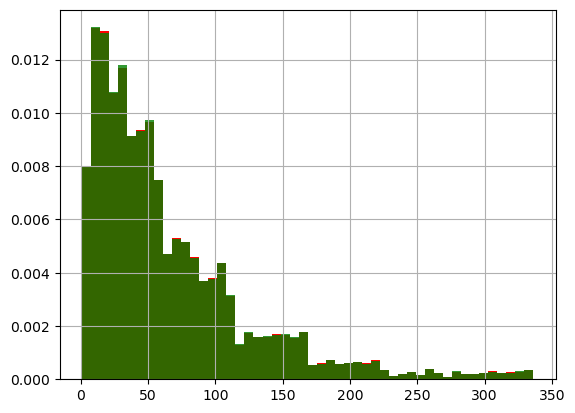

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: >

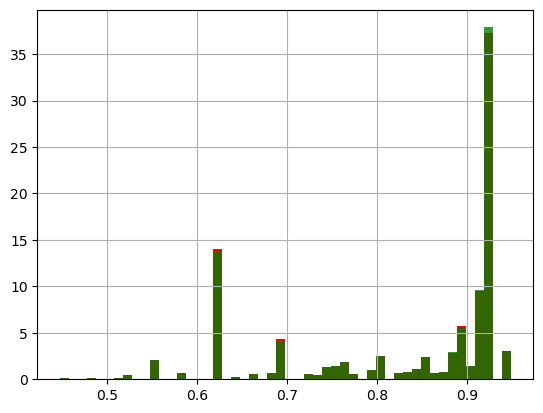

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

In [26]:
temp = pd.concat([
            df['enrolled_university'].value_counts() / len(df),
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)
temp.columns = ['original', 'cca']

temp


,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [27]:
temp = pd.concat([
            df['education_level'].value_counts() / len(df),
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
